# A2-TempPredict: Temperature Preparation for Simple RNN

This notebook prepares `BASEL_temp_mean` from `Data/weather_prediction_dataset.csv` for a simple PyTorch RNN.

Scenario:
- Feature: `BASEL_temp_mean`
- Sliding window: 14 days
- Forecast horizon: 1 day
- Train/test split: 70% train / 30% test
- 5-fold time-series cross-validation on the training set

## 1. Require setup


In [1]:
# In Google Colab, uncomment the next line if PyTorch is not installed:
# !pip install torch torchvision torchaudio scikit-learn pandas matplotlib

# If your file is in Google Drive, uncomment these two lines:
# from google.colab import drive
# drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
import torch
from torch.utils.data import Dataset, DataLoader
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


## 2. Load dataset and inspect the Basel temperature feature

In [13]:
data_path = os.path.join('Data', 'weather_prediction_dataset.csv')
df = pd.read_csv(data_path)
df['DATE'] = pd.to_datetime(df['DATE'].astype(str), format='%Y%m%d')
df = df.sort_values('DATE').reset_index(drop=True)

print('Dataset shape:', df.shape)
print('BASEL_temp_mean exists:', 'BASEL_temp_mean' in df.columns)
print(df[['DATE', 'BASEL_temp_mean']].head(10).to_string(index=False))

Dataset shape: (3654, 165)
BASEL_temp_mean exists: True
      DATE  BASEL_temp_mean
2000-01-01              2.9
2000-01-02              3.6
2000-01-03              2.2
2000-01-04              3.9
2000-01-05              6.0
2000-01-06              4.2
2000-01-07              4.7
2000-01-08              5.6
2000-01-09              4.6
2000-01-10              2.4


In [14]:
missing = df['BASEL_temp_mean'].isna().sum()
print('Missing values:', missing)
print('Value range:', df['BASEL_temp_mean'].min(), 'to', df['BASEL_temp_mean'].max())

Missing values: 0
Value range: -9.3 to 29.0


## 3. Visualize Basel daily mean temperature

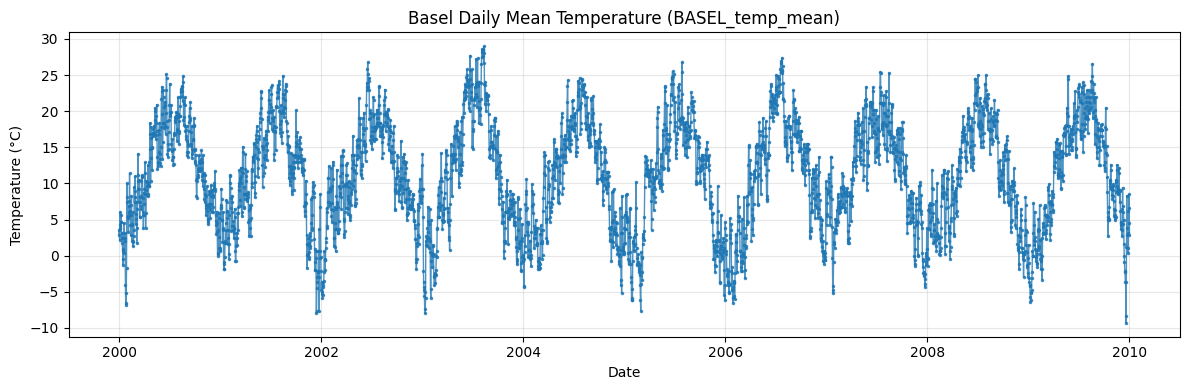

In [15]:
plt.figure(figsize=(12, 4))
plt.plot(df['DATE'], df['BASEL_temp_mean'], marker='.', markersize=3, linewidth=1, alpha=0.8)
plt.title('Basel Daily Mean Temperature (BASEL_temp_mean)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Train/test split (time-order preserved)

Use 70% of the raw series for training and 30% for testing before scaling and windowing. This keeps the split temporal and avoids leakage.

In [ ]:
series = df[['DATE', 'BASEL_temp_mean']].dropna().reset_index(drop=True)
values = series['BASEL_temp_mean'].values.reshape(-1, 1)

train_ratio = 0.70
train_size = int(len(values) * train_ratio)
train_values = values[:train_size]
test_values = values[train_size:]

print('Rows after dropna:', len(series))
print('Training rows used for scaling:', len(train_values))
print('Test rows used for scaling:', len(test_values))

Rows after dropna: 3654
Scaled range: 0.0 1.0


## 5. Normalize and create sliding windows for RNN input

We use a 14-day lookback and predict one day ahead. The model input shape is `(batch, seq_len, features)` with `features = 1`.

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_values).flatten()
test_scaled = scaler.transform(test_values).flatten()
values_scaled = np.concatenate([train_scaled, test_scaled])

def create_sliding_windows(data, window_size=14, horizon=1):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size + horizon - 1])
    return np.array(X), np.array(y)

window_size = 14
horizon = 1
X, y = create_sliding_windows(values_scaled, window_size=window_size, horizon=horizon)

print('Total sequences:', len(X))
print('X shape:', X.shape)
print('y shape:', y.shape)
print('Example X[0]:', X[0])
print('Example y[0]:', y[0])

Total sequences: 3640
X shape: (3640, 14)
y shape: (3640,)
Example X[0]: [0.31853786 0.33681462 0.3002611  0.34464752 0.39947781 0.35248042
 0.36553525 0.38903394 0.36292428 0.30548303 0.32637076 0.30548303
 0.28720627 0.25848564]
Example y[0]: 0.2088772845953003


In [7]:
train_ratio = 0.70
train_size = int(len(X) * train_ratio)

X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

print('Train samples:', len(X_train))
print('Test samples:', len(X_test))
print('Train ratio:', len(X_train) / len(X))
print('Test ratio:', len(X_test) / len(X))

Train samples: 2548
Test samples: 1092
Train ratio: 0.7
Test ratio: 0.3


## 6. Prepare training and testing sequence sets

In [8]:
tscv = TimeSeriesSplit(n_splits=5)
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
    print(f'Fold {fold}: train={len(train_idx)}, val={len(val_idx)}')

Fold 1: train=428, val=424
Fold 2: train=852, val=424
Fold 3: train=1276, val=424
Fold 4: train=1700, val=424
Fold 5: train=2124, val=424


## 8. Create PyTorch dataset and data loaders

In [9]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = SequenceDataset(X_train, y_train)
test_dataset = SequenceDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

batch_x, batch_y = next(iter(train_loader))
print('Train dataset size:', len(train_dataset))
print('Test dataset size:', len(test_dataset))
print('One batch X shape:', batch_x.shape)
print('One batch y shape:', batch_y.shape)

Train dataset size: 2548
Test dataset size: 1092
One batch X shape: torch.Size([32, 14, 1])
One batch y shape: torch.Size([32, 1])


## 9. Simple PyTorch RNN model skeleton

In [10]:
class SimpleRNN(torch.nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.rnn = torch.nn.RNN(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = torch.nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        return self.fc(out)

model = SimpleRNN().to(device)
print(model)

SimpleRNN(
  (rnn): RNN(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


## 10. Train the simple RNN and measure training time

This section trains the model on the 70% training split and measures total training time.


In [11]:
from time import perf_counter
from sklearn.metrics import mean_squared_error, mean_absolute_error

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
n_epochs = 30
history = {'train_loss': [], 'test_loss': [], 'test_mae': []}

start_time = perf_counter()
for epoch in range(1, n_epochs + 1):
    model.train()
    train_loss = 0.0
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        output = model(x_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x_batch.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    test_loss = 0.0
    test_mae = 0.0
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            output = model(x_batch)
            loss = criterion(output, y_batch)
            test_loss += loss.item() * x_batch.size(0)
            test_mae += torch.abs(output - y_batch).sum().item()
    test_loss /= len(test_loader.dataset)
    test_mae /= len(test_loader.dataset)

    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['test_mae'].append(test_mae)

    if epoch == 1 or epoch % 5 == 0 or epoch == n_epochs:
        print(f'Epoch {epoch}/{n_epochs}  train_loss={train_loss:.6f}  test_loss={test_loss:.6f}  test_mae={test_mae:.6f}')

total_training_time = perf_counter() - start_time
print(f'\nTotal training time: {total_training_time:.2f} seconds')
print(f'Average time per epoch: {total_training_time / n_epochs:.4f} seconds')


Epoch 1/30  train_loss=0.118499  test_loss=0.026478  test_mae=0.137388
Epoch 5/30  train_loss=0.007060  test_loss=0.006060  test_mae=0.062843
Epoch 10/30  train_loss=0.005600  test_loss=0.004970  test_mae=0.056984
Epoch 15/30  train_loss=0.004779  test_loss=0.004275  test_mae=0.052579
Epoch 20/30  train_loss=0.004193  test_loss=0.003753  test_mae=0.049215
Epoch 25/30  train_loss=0.003794  test_loss=0.003385  test_mae=0.046593
Epoch 30/30  train_loss=0.003522  test_loss=0.003129  test_mae=0.044533

Total training time: 6.96 seconds
Average time per epoch: 0.2321 seconds


## 11. Evaluate test performance and compare predictions


Test MSE (scaled): 0.003129
Test MAE (scaled): 0.044533
Test MSE (°C^2): 4.5902
Test MAE (°C): 1.7056


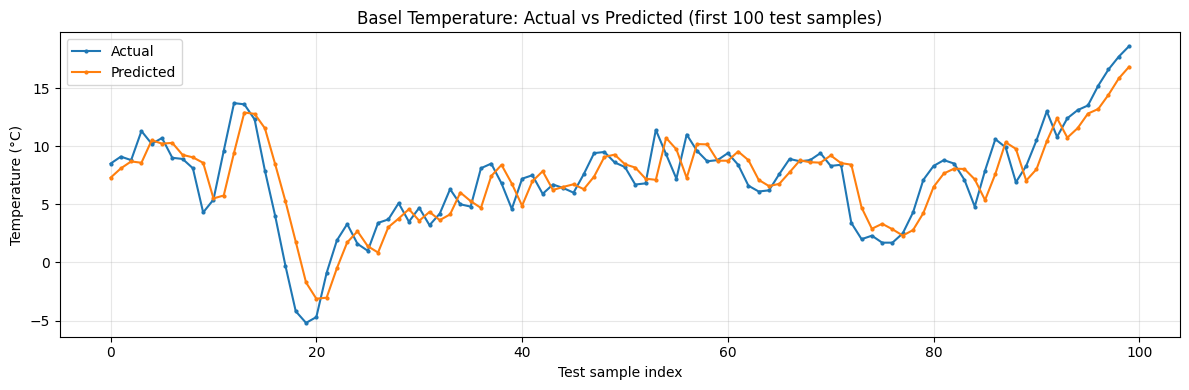

In [12]:
model.eval()
predictions = []
targets = []
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        output = model(x_batch).cpu().numpy().flatten()
        predictions.extend(output.tolist())
        targets.extend(y_batch.numpy().flatten().tolist())

predictions = np.array(predictions).reshape(-1, 1)
targets = np.array(targets).reshape(-1, 1)

predictions_inv = scaler.inverse_transform(predictions).flatten()
targets_inv = scaler.inverse_transform(targets).flatten()

mse_scaled = mean_squared_error(targets, predictions)
mae_scaled = mean_absolute_error(targets, predictions)
mse_celsius = mean_squared_error(targets_inv, predictions_inv)
mae_celsius = mean_absolute_error(targets_inv, predictions_inv)

print(f'Test MSE (scaled): {mse_scaled:.6f}')
print(f'Test MAE (scaled): {mae_scaled:.6f}')
print(f'Test MSE (°C^2): {mse_celsius:.4f}')
print(f'Test MAE (°C): {mae_celsius:.4f}')

plt.figure(figsize=(12, 4))
plt.plot(targets_inv[:100], label='Actual', marker='.', markersize=4)
plt.plot(predictions_inv[:100], label='Predicted', marker='.', markersize=4)
plt.title('Basel Temperature: Actual vs Predicted (first 100 test samples)')
plt.xlabel('Test sample index')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 12. Summary

The Basel temperature dataset is ready for a simple PyTorch RNN model. Continue by adding training/evaluation loops and comparing this scenario with other models.